In [28]:
# House Price Prediction — Ames Housing Dataset (Kaggle)
#Predicts house `SalePrice` using the Kaggle **"House Prices - Advanced Regression Techniques"** dataset (train.csv / test.csv, Ames, Iowa).

#Pipeline:
#1. Load train & test data
#2. Exploratory Data Analysis (EDA)
#3. Data Cleaning & Missing Value Imputation
#4. Feature Engineering + Categorical Encoding
#5. Model Training (Linear Regression, Ridge, Random Forest, Gradient Boosting)
#6. Model Evaluation (validation RMSE, R2)
#7. Generate Kaggle-style `submission.csv` on the real test set

In [29]:
## 1. Imports & Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")
np.random.seed(42)

%matplotlib inline

In [30]:
##Load Data
def load_data(train_path="train.csv", test_path="test.csv"):
    train = pd.read_csv(train_path)
    test = pd.read_csv(test_path)
    return train, test

In [31]:
train, test = load_data("train (1).csv", "test (2).csv")
print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (1460, 81)
Test shape: (1459, 80)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [44]:
## 3. Exploratory Data Analysis (EDA)
def perform_eda(train: pd.DataFrame):
    print("\n--- Shape ---")
    print("Train:", train.shape)

    print("\n--- SalePrice Summary ---")
    print(train["SalePrice"].describe())

    plt.figure(figsize=(8, 5))
    sns.histplot(train["SalePrice"], kde=True, color="steelblue")
    plt.title("SalePrice Distribution")
    plt.tight_layout()
    plt.savefig("price_distribution.png", dpi=150)
    plt.show()

    numeric_df = train.select_dtypes(include=[np.number])
    corr = numeric_df.corr()["SalePrice"].sort_values(ascending=False)
    top_features = corr.index[1:11]

    plt.figure(figsize=(10, 8))
    sns.heatmap(train[top_features.tolist() + ["SalePrice"]].corr(),
                annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Top 10 Features Correlated with SalePrice")
    plt.tight_layout()
    plt.savefig("correlation_heatmap.png", dpi=150)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.scatterplot(x="GrLivArea", y="SalePrice", data=train, alpha=0.6)
    plt.title("Living Area vs SalePrice")
    plt.tight_layout()
    plt.savefig("area_vs_price.png", dpi=150)
    plt.show()

    print("\nTop correlated features with SalePrice:\n", corr.head(11))
    print("\nEDA plots saved: price_distribution.png, correlation_heatmap.png, area_vs_price.png")


--- Shape ---
Train: (1460, 81)

--- SalePrice Summary ---
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


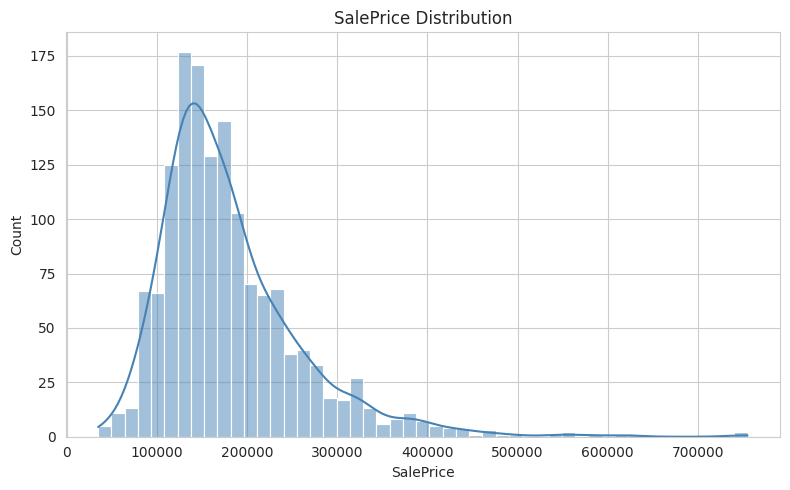

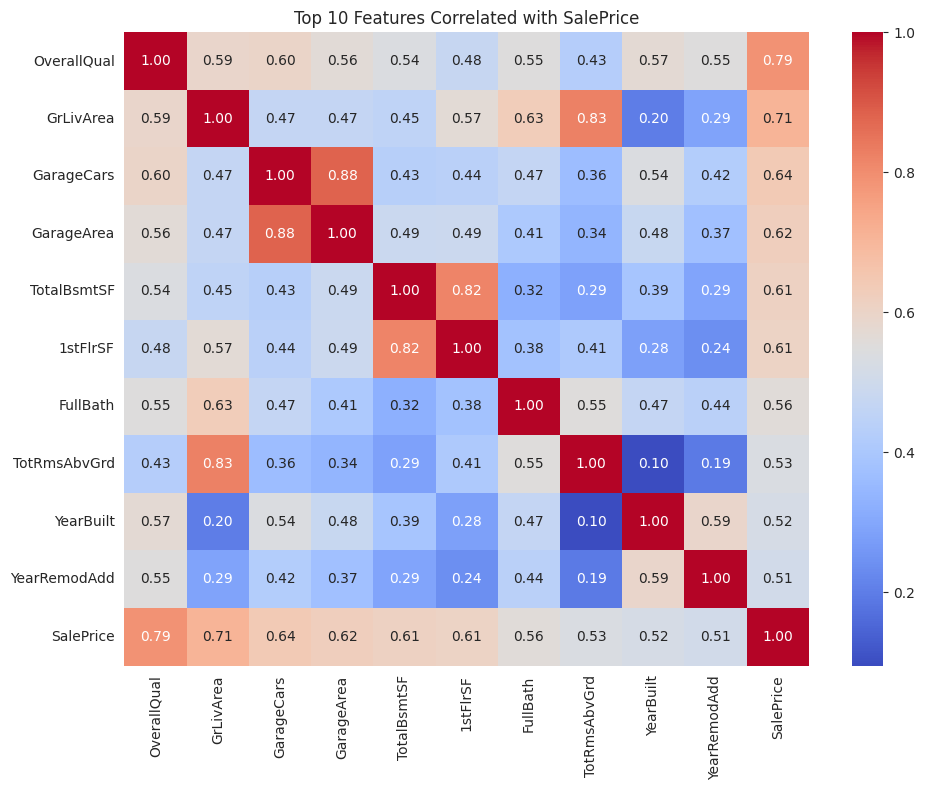

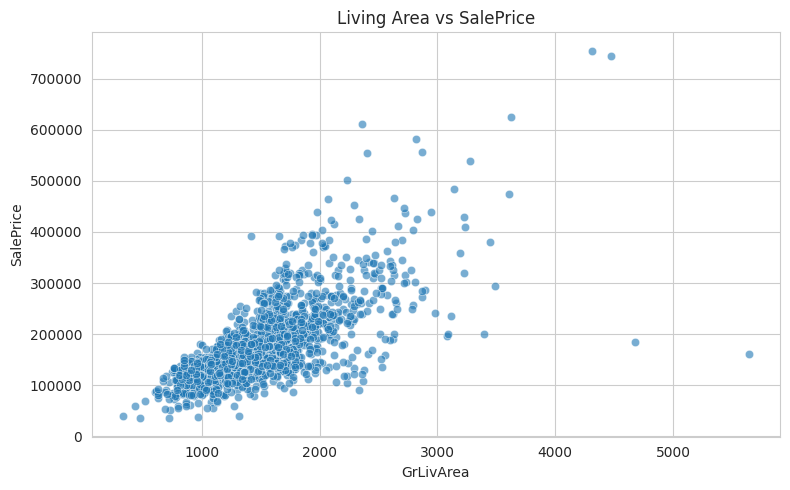


Top correlated features with SalePrice:
 SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64

EDA plots saved: price_distribution.png, correlation_heatmap.png, area_vs_price.png


In [45]:
perform_eda(train)

In [33]:
## 4. Data Cleaning & Feature Engineering
def clean_and_engineer(train: pd.DataFrame, test: pd.DataFrame):
    train = train.copy()
    test = test.copy()

    # Remove extreme, well-known outliers in this dataset
    train = train[~((train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000))]

    y = train["SalePrice"]
    test_ids = test["Id"]

    train_features = train.drop(["Id", "SalePrice"], axis=1)
    test_features = test.drop(["Id"], axis=1)

    # Combine so both sets get identical columns after encoding
    all_data = pd.concat([train_features, test_features], axis=0, ignore_index=True)

    # Categorical NAs often genuinely mean "feature not present" (e.g. no garage)
    cat_cols = all_data.select_dtypes(include="object").columns
    for col in cat_cols:
        all_data[col] = all_data[col].fillna("None")

    num_cols = all_data.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        all_data[col] = all_data[col].fillna(all_data[col].median())

    # Feature engineering
    all_data["TotalSF"] = all_data["TotalBsmtSF"] + all_data["1stFlrSF"] + all_data["2ndFlrSF"]
    all_data["HouseAge"] = all_data["YrSold"] - all_data["YearBuilt"]
    all_data["RemodAge"] = all_data["YrSold"] - all_data["YearRemodAdd"]
    all_data["TotalBath"] = (all_data["FullBath"] + 0.5 * all_data["HalfBath"]
                              + all_data["BsmtFullBath"] + 0.5 * all_data["BsmtHalfBath"])

    # One-hot encode categorical variables
    all_data = pd.get_dummies(all_data, drop_first=True)

    X = all_data.iloc[:len(train_features), :]
    X_test_final = all_data.iloc[len(train_features):, :]

    # Log-transform target (SalePrice is right-skewed) -> better model performance
    y_log = np.log1p(y)

    return X, y_log, X_test_final, test_ids

In [34]:
X, y_log, X_test_final, test_ids = clean_and_engineer(train, test)
print("Final feature matrix shape:", X.shape)
X.head()

Final feature matrix shape: (1458, 270)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLw,SaleType_New,SaleType_None,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,...,False,False,False,False,True,False,False,False,True,False
1,20,80.0,9600,6,8,1976,1976,0.0,978.0,0.0,...,False,False,False,False,True,False,False,False,True,False
2,60,68.0,11250,7,5,2001,2002,162.0,486.0,0.0,...,False,False,False,False,True,False,False,False,True,False
3,70,60.0,9550,7,5,1915,1970,0.0,216.0,0.0,...,False,False,False,False,True,False,False,False,False,False
4,60,84.0,14260,8,5,2000,2000,350.0,655.0,0.0,...,False,False,False,False,True,False,False,False,True,False


In [35]:
## 5. Train / Validation Split & Scaling
# Internal validation split (the real Kaggle test.csv has no SalePrice labels)
X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

# Scale features (helps Linear/Ridge Regression converge & compare fairly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print("Train:", X_train_scaled.shape, " Val:", X_val_scaled.shape, " Test:", X_test_scaled.shape)

Train: (1166, 270)  Val: (292, 270)  Test: (1459, 270)


In [36]:
def train_models(X_train, y_train):
    models = {
        "Linear Regression": LinearRegression(),
        "Ridge Regression": Ridge(alpha=10),
        "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42),
        "Gradient Boosting": GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                                         max_depth=3, random_state=42),
    }
    for name, model in models.items():
        model.fit(X_train, y_train)
    return models

In [37]:
models = train_models(X_train_scaled, y_train)
print("Models trained:", list(models.keys()))

Models trained: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'Gradient Boosting']


In [38]:
def evaluate_models(models: dict, X_val, y_val):
    results = []
    for name, model in models.items():
        preds_log = model.predict(X_val)

        # Convert back from log scale to actual price scale for interpretable metrics
        preds = np.expm1(preds_log)
        actual = np.expm1(y_val)

        mae = mean_absolute_error(actual, preds)
        rmse = np.sqrt(mean_squared_error(actual, preds))
        r2 = r2_score(actual, preds)

        results.append({"Model": name, "MAE": round(mae, 2),
                         "RMSE": round(rmse, 2), "R2 Score": round(r2, 4)})

    results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False)
    print("\n--- Model Evaluation (on validation split) ---")
    print(results_df.to_string(index=False))
    return results_df

In [39]:
results_df = evaluate_models(models, X_val_scaled, y_val)
results_df


--- Model Evaluation (on validation split) ---
            Model      MAE     RMSE  R2 Score
Gradient Boosting 14236.33 20187.36    0.9262
 Ridge Regression 15252.75 21585.09    0.9157
Linear Regression 15512.72 21877.59    0.9134
    Random Forest 16744.90 24023.33    0.8955


,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,14236.33,20187.36,0.9262
1,Ridge Regression,15252.75,21585.09,0.9157
0,Linear Regression,15512.72,21877.59,0.9134
2,Random Forest,16744.90,24023.33,0.8955


In [40]:
def plot_feature_importance(model, feature_names, top_n=15):
    importance = pd.Series(model.feature_importances_, index=feature_names)
    importance = importance.sort_values(ascending=False).head(top_n).sort_values()

    plt.figure(figsize=(9, 7))
    importance.plot(kind="barh", color="teal")
    plt.title(f"Top {top_n} Feature Importances")
    plt.tight_layout()
    plt.savefig("feature_importance.png", dpi=150)
    plt.show()
    print("Saved: feature_importance.png")

Best model: Gradient Boosting


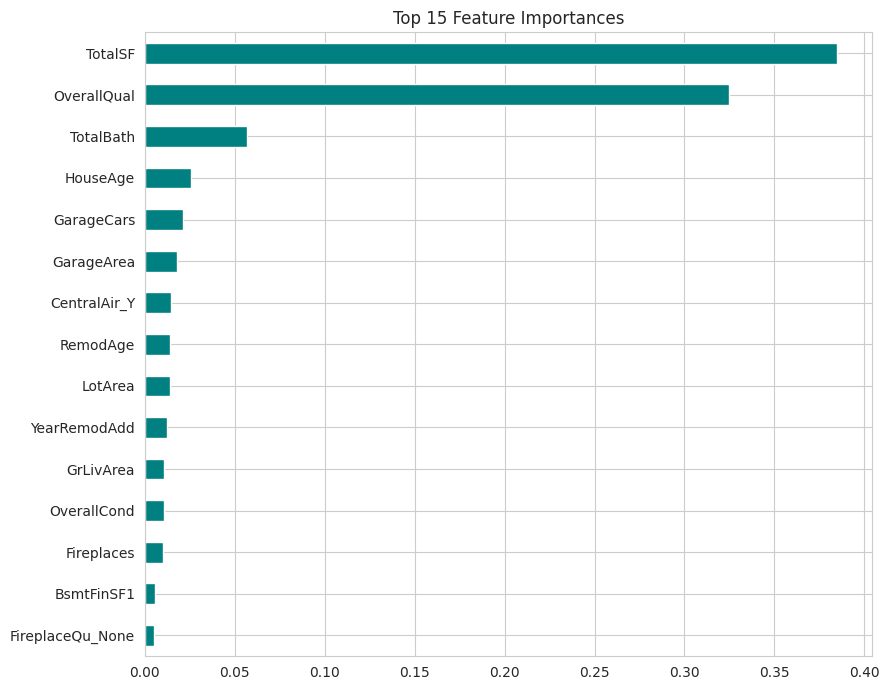

Saved: feature_importance.png


In [41]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

if hasattr(best_model, "feature_importances_"):
    plot_feature_importance(best_model, X.columns)
else:
    print(f"{best_model_name} has no feature_importances_ (not tree-based).")

In [42]:
def generate_submission(model, X_test_final, test_ids, filename="submission.csv"):
    preds_log = model.predict(X_test_final)
    preds = np.expm1(preds_log)  # reverse the log1p transform

    submission = pd.DataFrame({"Id": test_ids, "SalePrice": preds})
    submission.to_csv(filename, index=False)
    print(f"Saved: {filename}")

In [43]:
generate_submission(best_model, X_test_scaled, test_ids)
print("\nDone! Check submission.csv and the saved plots.")

Saved: submission.csv

Done! Check submission.csv and the saved plots.
